In [1]:
# Import necessary libraries for 3D plotting and data processing
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle as pkl
import pandas as pd
import numpy as np
import os
import mlacca_functions as mlcf

In [2]:
# Load van Krevelen data with PAH classification
df = pd.read_csv('data\\csv_files\\new_vk_areas_with_pahs.csv')

# Configuration: output format and directories
plot_format = 'png'  # Format for saving plots (png, svg, pdf, etc.)
models_dir = 'data\\models'  # Directory containing trained ML models
save_plots_dir = f'data\\plots\\decision_boundaries\\partial_3d_plots'

# Define axis limits for 3D van Krevelen space (O/C, H/C, N/C)
xlim = (0, 1.8)   # O/C ratio limits
ylim = (0.2, 2.8) # H/C ratio limits
zlim = (0, 0.75)   # N/C ratio limits

In [3]:
# Load all trained classification models from pickle files
model_files = os.listdir(models_dir)
model_dict = {}

for file in model_files:
        with open(f'{models_dir}\\{file}', "rb") as f:
                # Store models in dictionary with filename (without .pkl) as key
                model_dict[file.replace('.pkl','')] = pkl.load(f)

In [4]:
def like_label(label: str):
    """
    Format molecular class labels for plot legends.
    
    Args:
        label: Raw label string (e.g., 'tannin', 'pah')
    
    Returns:
        Formatted label string (e.g., 'Tannin-like', 'PAH-like')
    """
    return f'{label.capitalize().replace('_',' ')}-like' if label != 'pah' else 'PAH-like'


def create_grid(density):
    """
    Create a 3D grid for visualizing decision boundaries in van Krevelen space.
    
    Args:
        density: Number of points along each axis
    
    Returns:
        numpy array of shape (density^3, 3) containing grid points [O/C, H/C, N/C]
    """
    xx, yy, zz = np.meshgrid(np.linspace(min(xlim), max(xlim), density),
                             np.linspace(min(ylim), max(ylim), density),
                             np.linspace(min(zlim), max(zlim), density))

    # Flatten and stack coordinates
    xx = xx.flatten()
    yy = yy.flatten()
    zz = zz.flatten()
    grid = np.vstack((xx, yy, zz)).T

    return grid


def standard_3d_plot_features(ax, grid, label_fontsize=14):
    """
    Apply consistent styling to 3D scatter plots.
    
    Args:
        ax: matplotlib 3D axis object
        grid: Grid data for setting axis ticks
        label_fontsize: Font size for axis labels
    """
    # Set axis labels
    ax.set_xlabel('O/C', fontsize=label_fontsize, labelpad=15)
    ax.set_ylabel('H/C', fontsize=label_fontsize, labelpad=15)
    ax.set_zlabel('N/C', fontsize=label_fontsize, labelpad=8)

    # Configure axis ticks for each dimension
    mlcf.set_axis_ticks(grid[:,0], ax, axis='x', major_ticks_interval=.4, 
                       minor_ticks_interval=None, rounding=1, 
                       lower_lim=min(xlim), upper_lim=max(xlim))
    mlcf.set_axis_ticks(grid[:,1], ax, axis='y', major_ticks_interval=.4, 
                       minor_ticks_interval=None, rounding=1, 
                       lower_lim=min(ylim), upper_lim=max(ylim))
    mlcf.set_axis_ticks(grid[:,2], ax, axis='z', major_ticks_interval=.25, 
                       minor_ticks_interval=None, rounding=1, 
                       lower_lim=min(zlim), upper_lim=max(zlim))

    # Add grid and adjust aspect ratio
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_box_aspect(None, zoom=0.85)


def subplots_3d_molecclass(plot_list, ypred, legend_ax, label_fontsize=14):
    """
    Draw multiple 3D subplots showing molecular class predictions.
    
    Args:
        plot_list: List of [axis, grid, classes, view_angle, title] for each subplot
        ypred: Predicted molecular classes for grid points
        legend_ax: Axis to add the legend to
        label_fontsize: Font size for axis labels
    """
    for plot in plot_list:
        # Filter predictions to show only specified classes
        idx = np.where([x in plot[2] for x in ypred])[0]
        
        # Create scatter plot with class-specific colors
        plot[0].scatter(plot[1][:,0][idx],
                        plot[1][:,1][idx],
                        plot[1][:,2][idx],
                        c=[mlcf.vk_region_colours[x] for x in ypred[idx]],
                        alpha=1, edgecolor='k', lw=.1)

        # Apply standard plot styling
        standard_3d_plot_features(plot[0], plot[1], label_fontsize=label_fontsize)

        # Set view angle and title
        plot[0].view_init(**plot[3])
        plot[0].set_title(**plot[4], fontsize=24)

        # Add legend to specified axis
        if plot[0] == legend_ax:
            for cat in np.unique(ypred):
                plot[0].scatter(10, 10, 10, c=mlcf.vk_region_colours[cat],
                              alpha=1, edgecolor='k', lw=.1, 
                              label=like_label(cat), s=100)
            plot[0].legend(framealpha=1, bbox_to_anchor=(1, 1.05), 
                          loc='upper left', borderaxespad=0, fontsize=18)


def subplots_3d_proba(plot_list: list[list[plt.Axes, np.ndarray, dict, dict]],
                      yproba, cmap='seismic', label_fontsize=14, **kwargs):
    """
    Draw multiple 3D subplots showing class probability predictions.
    
    Args:
        plot_list: List of [axis, grid, view_angle, title] for each subplot
        yproba: Predicted probabilities for grid points
        cmap: Colormap for probability visualization
        label_fontsize: Font size for axis labels
        **kwargs: Additional arguments passed to scatter plot
    """
    # Normalize probability values between 0 and 1
    norm_values = np.round([0, 1], 2)
    norm = mpl.colors.Normalize(vmin=norm_values[0], vmax=norm_values[1])
    
    for plot in plot_list:
        # Create scatter plot colored by probability
        ax_plot = plot[0].scatter(plot[1][:,0],
                                  plot[1][:,1],
                                  plot[1][:,2],
                                  c=yproba, cmap=cmap, norm=norm, **kwargs)
        
        # Apply standard plot styling
        standard_3d_plot_features(plot[0], plot[1], label_fontsize=label_fontsize)

        # Set view angle and title
        plot[0].view_init(**plot[2])
        plot[0].set_title(**plot[3], fontsize=24)

        # Add colorbar to last subplot
        if plot == plot_list[-1]:
            cbar = plot[0].get_figure().colorbar(ax_plot, 
                                                ticks=np.linspace(norm_values[0], norm_values[1], 5),
                                                location='bottom')
            cbar.set_label(label='Predicted compound class probability', size=14)

In [5]:
# Create 3D grid for model predictions (60x60x60 points)
grid = create_grid(density=60)

## KNN

In [6]:
# Generate predictions for K-Nearest Neighbors model across the grid
y_pred_knn = model_dict['knn'].predict(grid)

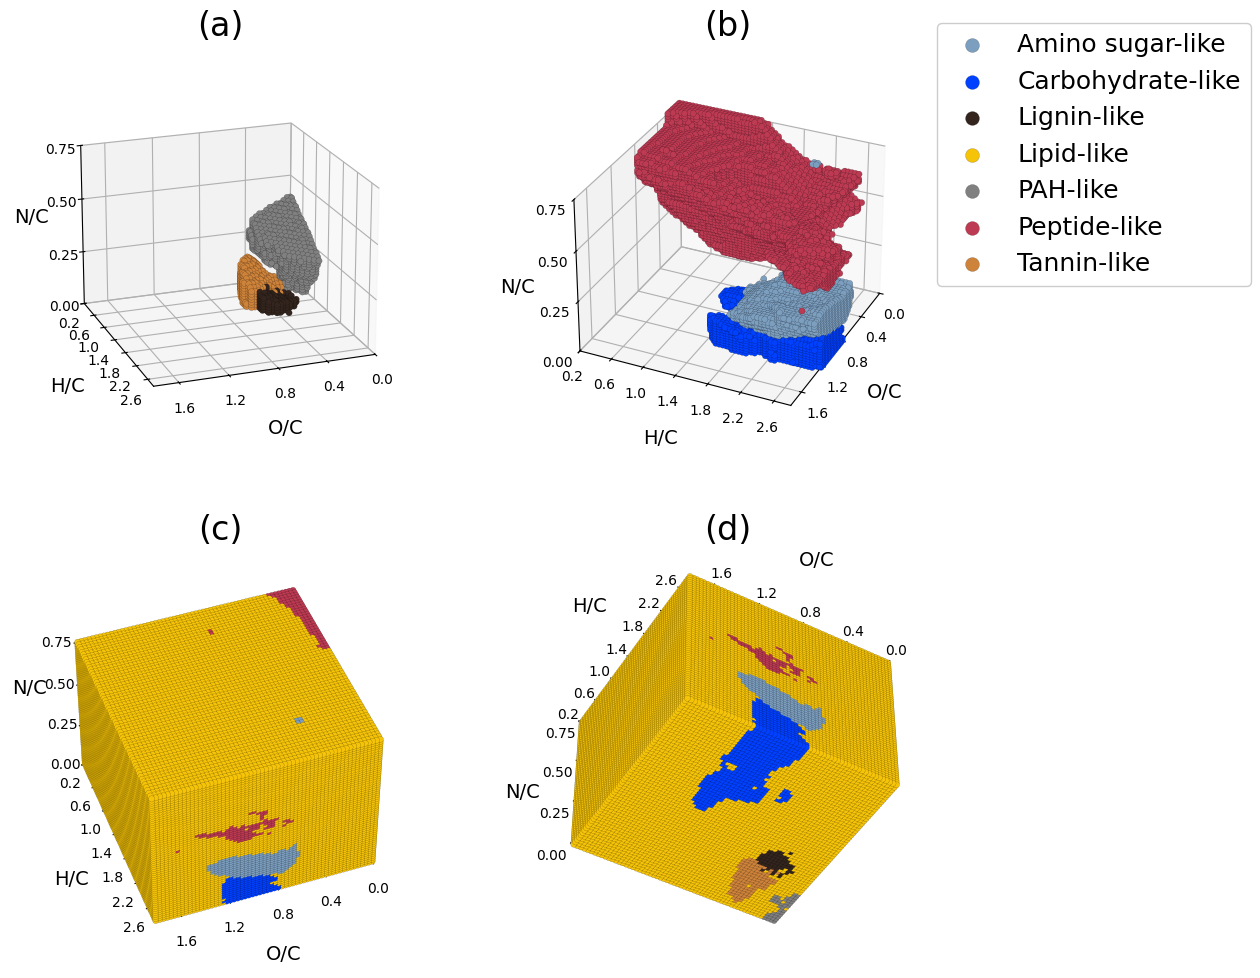

In [7]:
# Create 4-panel figure showing KNN decision boundaries from different perspectives
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

# Define plot configurations: [axis, grid, classes_to_show, view_angle, title]
plot_list = [
    [ax1, grid, np.sort(['tannin', 'lignin', 'pah']), dict(elev=20, azim=70), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate', 'peptide', 'amino_sugar']), dict(elev=30, azim=25), dict(label='(b)')],
    [ax3, grid, np.sort(['lipid', 'peptide', 'amino_sugar','carbohydrate']), dict(elev=45, azim=70), dict(label='(c)')],
    [ax4, grid, np.sort(['tannin', 'lignin', 'lipid', 'carbohydrate', 'pah', 'amino_sugar','peptide']), dict(elev=-45, azim=60), dict(label='(d)')],    
]

subplots_3d_molecclass(plot_list, y_pred_knn, ax2)

# Save high-resolution figure
fig.savefig(f'{save_plots_dir}\\knn.{plot_format}', dpi=600, facecolor='#fff', bbox_inches='tight')

## GNB

In [8]:
# Generate predictions for Gaussian Naive Bayes model across the grid
y_pred_gnb = model_dict['gnb'].predict(grid)

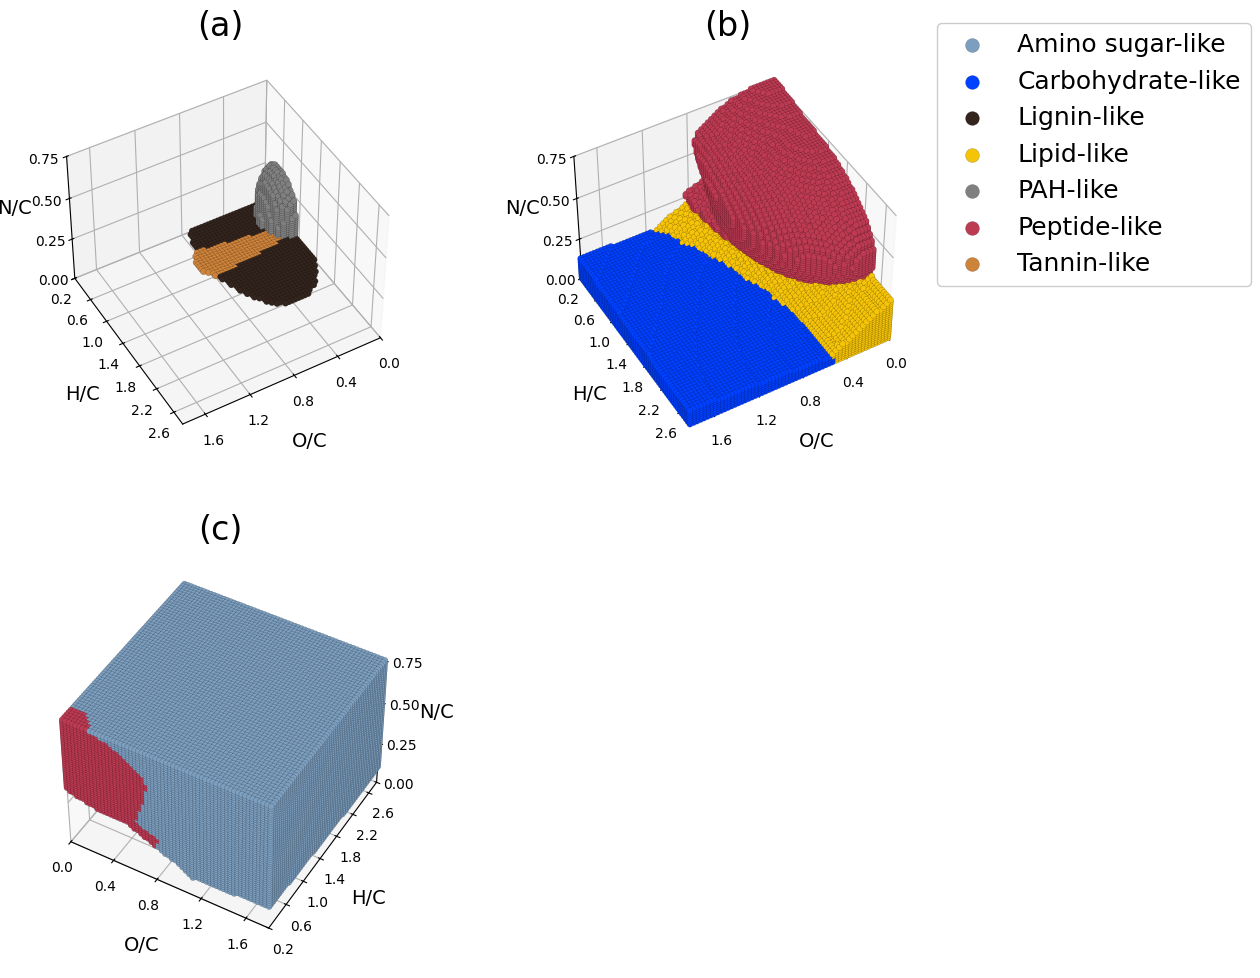

In [9]:
# Create 3-panel figure showing GNB decision boundaries
fig = plt.figure(figsize=(12, 12)) #width, height in inches

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')

# Define plot configurations for different molecular class groupings
plot_list = [
    [ax1, grid, np.sort(['tannin', 'lignin', 'pah']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate', 'lipid', 'peptide']), dict(elev=45, azim=60), dict(label='(b)')],
    [ax3, grid, np.sort(['amino_sugar','peptide']), dict(elev=45, azim=-60), dict(label='(c)')],
]

subplots_3d_molecclass(plot_list, y_pred_gnb, ax2)

# Save high-resolution figure
fig.savefig(f'{save_plots_dir}\\gnb.{plot_format}', dpi=600, facecolor='#fff', bbox_inches='tight')

## Poly SVM

In [10]:
# Generate predictions for Polynomial SVM model across the grid
y_pred_svm_poly = model_dict['svm_poly'].predict(grid)

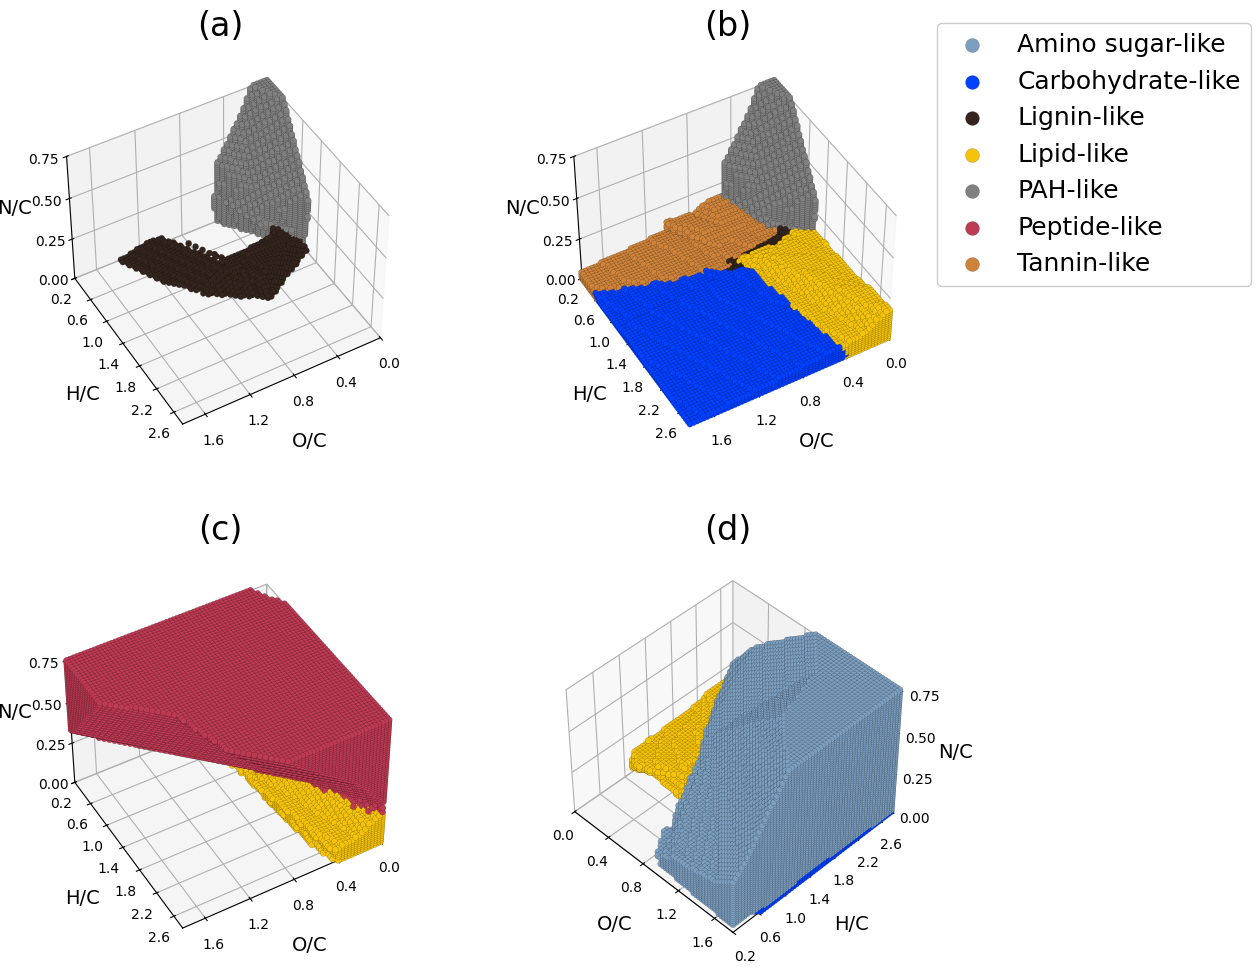

In [11]:
# Create 4-panel figure showing Polynomial SVM decision boundaries
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

# Define plot configurations highlighting different class boundaries
plot_list = [
    [ax1, grid, np.sort(['lignin', 'pah']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['tannin', 'carbohydrate', 'lipid', 'lignin','pah']), dict(elev=45, azim=60), dict(label='(b)')],
    [ax3, grid, np.sort(['peptide', 'lipid']), dict(elev=45, azim=60), dict(label='(c)')],
    [ax4, grid, np.sort(['amino_sugar','carbohydrate','lipid']), dict(elev=45, azim=-45), dict(label='(d)')],
]

subplots_3d_molecclass(plot_list, y_pred_svm_poly, ax2)

# Save high-resolution figure
fig.savefig(f'{save_plots_dir}\\svm_poly.{plot_format}', dpi=600, facecolor='#fff', bbox_inches='tight')

## RBF SVM

In [12]:
# Generate predictions for RBF SVM model across the grid
y_pred_svm_rbf = model_dict['svm_rbf'].predict(grid)

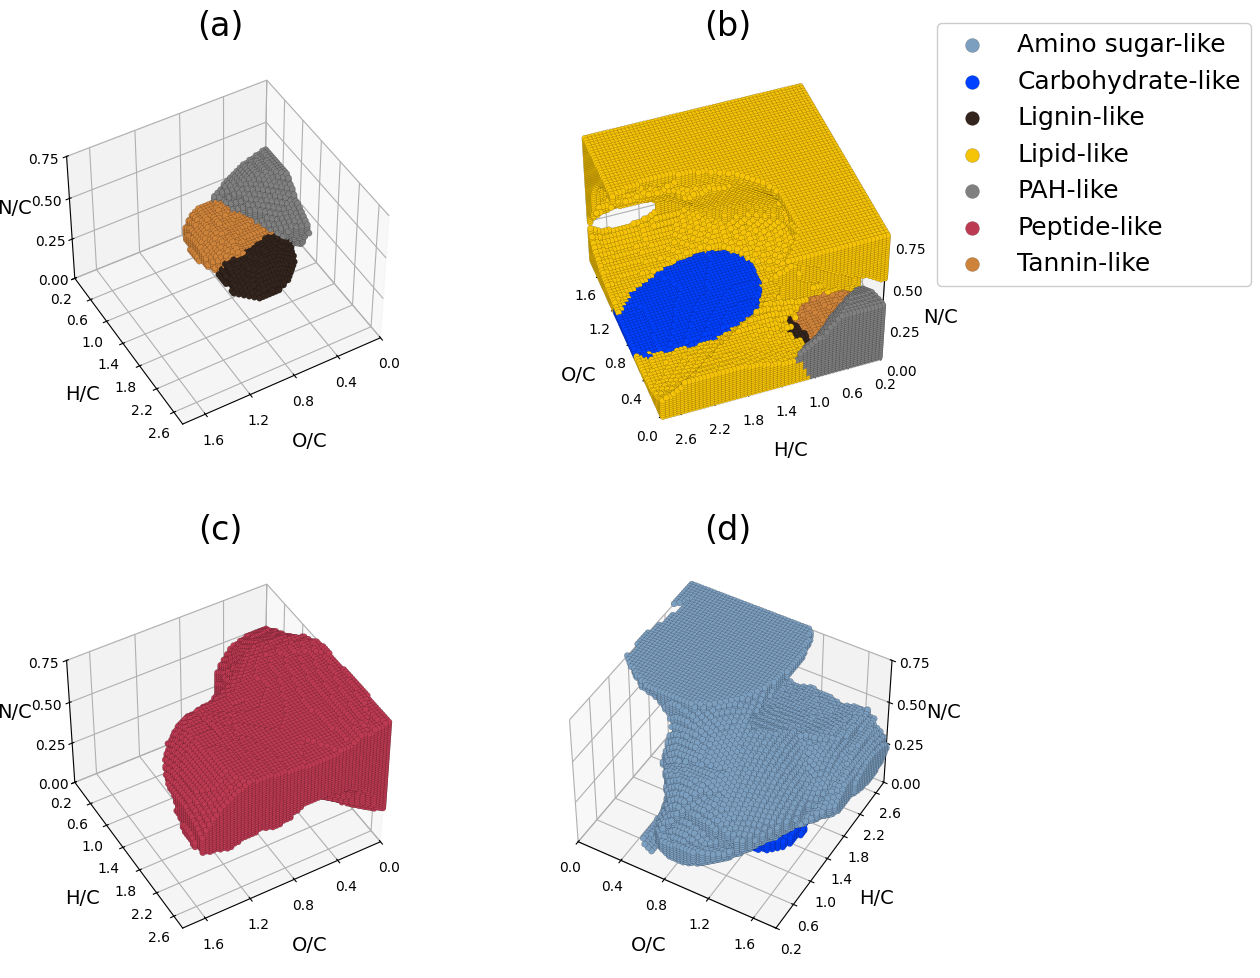

In [13]:
# Create 4-panel figure showing RBF SVM decision boundaries
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

# Define plot configurations with varied viewing angles
plot_list = [
    [ax1, grid, np.sort(['lignin', 'pah', 'tannin']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate', 'lipid','lignin', 'pah', 'tannin']), dict(elev=45, azim=160), dict(label='(b)')],
    [ax3, grid, np.sort(['peptide']), dict(elev=45, azim=60), dict(label='(c)')],
    [ax4, grid, np.sort(['amino_sugar','carbohydrate']), dict(elev=45, azim=-60), dict(label='(d)')],
]

subplots_3d_molecclass(plot_list, y_pred_svm_rbf, ax2)

# Save high-resolution figure
fig.savefig(f'{save_plots_dir}\\svm_rbf.{plot_format}', dpi=600, facecolor='#fff', bbox_inches='tight')